In [2]:
import pandas as pd
import seaborn as sns
import numpy as np
import matplotlib.pyplot as plt

In [3]:
df=pd.read_csv(r"C:\Users\USER\Downloads\messy_ecommerce_sales_data.csv")

In [4]:
df

,ID,Customer_Name,Order_ID,Order_Date,Product,Category,Quantity,Price,Payment_Method,Status,Total
0,100,Customer_100,ORD-41285,11/22/2024,Blender,Home,3,38,Cash on Delivery,Shipped,114.000
1,101,Customer_101,ORD-35783,7/5/2025,Smartphone,Electronics,2,abd,PayPal,Processing,NaN
2,102,Customer_102,ORD-84355,12/23/2024,Tennis Racket,Sports,1,389.05,PayPal,Delivered,389.050
3,103,Customer_103,ORD-57811,3/19/2025,Science,Books,5,233.92,PayPal,Processing,1169.600
4,104,Customer_104,ORD-93614,10/20/2025,Biography,Books,1,552.51,Cash on Delivery,Processing,552.510
...,...,...,...,...,...,...,...,...,...,...,...
98,198,Customer_198,ORD-14608,7/27/2025,Vacuum,NaN,2,497.01,Cash on Delivery,Shipped,994.020
99,199,Customer_199,ORD-82922,1/22/2025,Blender,Home,5,372.28,Credit Card,Shipped,1861.400
100,175,Customer_175,ORD-56651,2/24/2025,Headphones,Electronics,1,111.36,Credit Card,Processing,77.952
101,142,Customer_142,ORD-69018,10/30/2025,Shoes,Clothing,5,645.26,Credit Card,Shipped,3226.300


In [5]:
pd.options.display.max_rows=103

In [6]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 103 entries, 0 to 102
Data columns (total 11 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   ID              103 non-null    int64  
 1    Customer_Name  103 non-null    object 
 2   Order_ID        103 non-null    object 
 3   Order_Date      103 non-null    object 
 4   Product         103 non-null    object 
 5    Category       95 non-null     object 
 6   Quantity        98 non-null     object 
 7   Price           98 non-null     object 
 8   Payment_Method  103 non-null    object 
 9   Status          103 non-null    object 
 10  Total           89 non-null     float64
dtypes: float64(1), int64(1), object(9)
memory usage: 9.0+ KB


In [7]:
df.nunique()

ID                100
 Customer_Name    100
Order_ID          100
Order_Date         86
Product            21
 Category           9
Quantity            8
Price              94
Payment_Method      4
Status              5
Total              88
dtype: int64

In [8]:
df.duplicated().sum()

np.int64(1)

In [9]:
df=df.drop_duplicates()

In [10]:
#df

In [11]:
df.isnull().sum()

ID                 0
 Customer_Name     0
Order_ID           0
Order_Date         0
Product            0
 Category          8
Quantity           5
Price              5
Payment_Method     0
Status             0
Total             14
dtype: int64

In [12]:
df[' Category'].unique()

array(['Home', 'Electronics', 'Sports', 'Books', 'sports', 'Clothing',
       'electronic', 'ELECTRONICS', 'electronics', nan], dtype=object)

In [110]:
df[' Category']=df[' Category'].replace(['electronic','ELECTRONICS','electronics','Electronicss'],'Electronics', regex=True)

C:\Users\USER\AppData\Local\Temp\ipykernel_8816\3368268794.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df[' Category']=df[' Category'].replace(['electronic','ELECTRONICS','electronics','Electronicss'],'Electronics', regex=True)


In [151]:
df[' Category']

In [15]:
df[' Category']=df[' Category'].replace( 'sports','Sports', regex=True)

C:\Users\USER\AppData\Local\Temp\ipykernel_8816\2295238418.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df[' Category']=df[' Category'].replace( 'sports','Sports', regex=True)


In [ ]:
df['Quantity']=df['Quantity'].str.strip(r'-a')

In [143]:
df['Quantity'].unique()

array(['3', '2', '1', '5', nan, '4'], dtype=object)

In [ ]:
df['Price']=df['Price'].replace('four hundred','400',regex=True)
df['Price']=df['Price'].str.strip('-abd$')

In [144]:
df['Price'].unique()

array(['38', nan, '389.05', '233.92', '552.51', '122.06', '978.63',
       '587.68', '600.29', '168.34', '400', '865.77', '752.13', '411.81',
       '413.13', '796.84', '10000', '247.82', '438.19', '300', '523.01',
       '556.93', '615.91', '765.69', '836.8', '336.02', '898.69',
       '736.71', '616.63', '266.7', '343.24', '591.53', '446.19',
       '696.71', '100', '531.06', '681.38', '588.98', '546.04', '645.26',
       '826.77', '849.07', '860.99', '705.42', '596.15', '660.98',
       '896.38', '206.19', '457.16', '233.11', '278.9', '789.64', '40.95',
       '275.1', '933.58', '163.16', '242.52', '209.32', '155.76',
       '235.26', '587.64', '443.13', '569.38', '593.93', '141.49',
       '582.13', '741.63', '688.68', '942.76', '351.89', '187.48',
       '111.36', '530.52', '69.48', '472.14', '868.67', '418.38',
       '266.48', '538.35', '101.19', '730.92', '365.34', '882.96',
       '504.05', '814.68', '920.37', '881.02', '203.63', '522.02',
       '944.54', '817.46', '160.16', 

In [145]:
df['Price']=df['Price'].replace('',np.nan)

C:\Users\USER\AppData\Local\Temp\ipykernel_8816\2122556369.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df['Price']=df['Price'].replace('',np.nan)


In [146]:
df['Product'].unique()

array(['Blender', 'Smartphone', 'Tennis Racket', 'Science', 'Biography',
       'Basketball', 'Comics', 'Shoes', 'Fiction', 'Microwave',
       'Yoga Mat', 'Vacuum', 'Lamp', 'T-shirt', 'Smartwatch',
       'Headphones', 'Football', 'Laptop', 'Jacket', 'shoes', 'Jeans'],
      dtype=object)

In [147]:
df['Status'].unique()

array(['Shipped', 'Processing', 'Delivered', 'Cancelled', 'Returned'],
      dtype=object)

In [355]:
df['Total']

# NUll values handling

In [246]:
df[df.isna().any(axis=1)]

,ID,Customer_Name,Order_ID,Order_Date,Product,Category,Quantity,Price,Payment_Method,Status,Total
92,192,Customer_192,ORD-35144,NaN,Jacket,Clothing,4,203,Credit Card,Returned,2748.927


In [242]:
df[df[' Category'].isna()]

,ID,Customer_Name,Order_ID,Order_Date,Product,Category,Quantity,Price,Payment_Method,Status,Total


In [108]:
df.loc[df['Product'].isin(['Smartphone','Laptop','Headphones','Smartwatch']),' Category']='Electronics' 
df.loc[df['Product'].isin(['Shoes','Jeans']),' Category']='Clothing'
df.loc[df['Product'].isin(['Science','Comics','Fiction','Biography']),' Category']='Books'

df.loc[df['Product'].isin(['Vacuum','Lamp','Blender','Microwave']),' Category']='Home'
df.loc[df['Product'].isin(['Yoga Mat','Basketball','Tennis Racket','Football']),' Category']='Sports'

In [175]:
df[df['Quantity'].isna()]

,Product,ID,Customer_Name,Order_ID,Order_Date,Category,Quantity,Price,Payment_Method,Status,Total


In [174]:
df['Quantity']=(df['Quantity'].astype(float).interpolate()).astype(int)

C:\Users\USER\AppData\Local\Temp\ipykernel_8816\658096661.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df['Quantity']=(df['Quantity'].astype(float).interpolate()).astype(int)


In [244]:
df[df['Price'].isna()]

,ID,Customer_Name,Order_ID,Order_Date,Product,Category,Quantity,Price,Payment_Method,Status,Total


In [189]:
#df.set_index(['Product',' Category','Quantity'],inplace=True)
df.reset_index(inplace=True)

In [187]:
df['Price']=(df['Price'].astype(float).interpolate()).astype(int)

C:\Users\USER\AppData\Local\Temp\ipykernel_8816\257763473.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df['Price']=(df['Price'].astype(float).interpolate()).astype(int)


In [354]:
df['Total']

In [211]:
df['Total']=(df['Total'].astype(float).interpolate()).round(3)

C:\Users\USER\AppData\Local\Temp\ipykernel_8816\2963140109.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df['Total']=(df['Total'].astype(float).interpolate()).round(3)


In [154]:
#df[df['Product']=='Smartphone'] 

In [155]:
#df['Product'].unique()

In [156]:
#df[df[' Category']=='Sports']

In [157]:
#df[df['Price'].isna()]

In [216]:
#df.set_index(['ID', ' Customer_Name', 'Order_ID', 'Order_Date','Product', ' Category'],inplace=True)
df.reset_index(inplace=True)
#df.set_index(['Quantity','Price'],inplace=True)


In [221]:
#df

In [214]:
df.columns

Index(['Quantity', 'Price', 'ID', ' Customer_Name', 'Order_ID', 'Order_Date',
       'Product', ' Category', 'Payment_Method', 'Status', 'Total'],
      dtype='object')

In [207]:
df.loc[df['Quantity']=='']

,Quantity,Price,ID,Customer_Name,Order_ID,Order_Date,Product,Category,Payment_Method,Status,Total


In [327]:
df.dropna(inplace=True)

C:\Users\USER\AppData\Local\Temp\ipykernel_8816\1379821321.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df.dropna(inplace=True)


# standardize

In [233]:
df['Order_Date']=df['Order_Date'].str.strip('abc')

C:\Users\USER\AppData\Local\Temp\ipykernel_8816\1542852853.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df['Order_Date']=df['Order_Date'].str.strip('abc')


In [230]:
#df.head(10)

In [251]:
#df['Order_Date']=df['Order_Date'].replace('',np.nan)

#df['Order_Date']


In [250]:
df['Order_Date']=pd.to_datetime(df['Order_Date'],format='%m/%d/%Y',errors='coerce')

C:\Users\USER\AppData\Local\Temp\ipykernel_8816\4074361214.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df['Order_Date']=pd.to_datetime(df['Order_Date'],format='%m/%d/%Y',errors='coerce')


# EDA

In [257]:
df.describe()

,ID,Order_Date,Quantity,Price,Total
count,102.000000,100,102.000000,102.000000,102.000000
mean,149.676471,2025-04-24 23:16:48,3.078431,644.274510,1190.466745
min,100.000000,2023-01-05 00:00:00,1.000000,38.000000,-20000.000000
25%,125.250000,2025-02-09 00:00:00,2.000000,268.250000,586.670000
50%,149.500000,2025-05-18 12:00:00,3.000000,530.500000,1191.100000
75%,174.750000,2025-08-04 00:00:00,4.750000,723.750000,2232.157500
max,199.000000,2025-11-06 00:00:00,5.000000,10000.000000,4722.700000
std,28.843779,NaN,1.493791,1084.644151,2684.161246


In [292]:
df.groupby(' Category')[['Quantity','Price','Total']].agg(['min','max','mean'])

Quantity               Price                         Total  \
                 min max      mean   min    max         mean       min   
 Category                                                                
Books              1   5  3.434783   141    942   568.434783    282.98   
Clothing           1   5  3.882353    40    836   493.941176  -2957.65   
Electronics        1   4  1.812500    69    933   454.250000     69.48   
Home               1   5  3.200000    38  10000  1065.720000 -20000.00   
Sports             1   5  2.857143   122    868   492.095238    206.19   

                                   
                 max         mean  
 Category                          
Books        4481.90  1816.354565  
Clothing     4133.85  1785.874824  
Electronics  2648.88   862.397938  
Home         4722.70   202.050320  
Sports       4245.35  1449.616952

In [272]:
df.corr(numeric_only=True)

,ID,Quantity,Price,Total
ID,1.000000,-0.092012,-0.150282,0.169441
Quantity,-0.092012,1.000000,-0.015419,0.295108
Price,-0.150282,-0.015419,1.000000,-0.797197
Total,0.169441,0.295108,-0.797197,1.000000


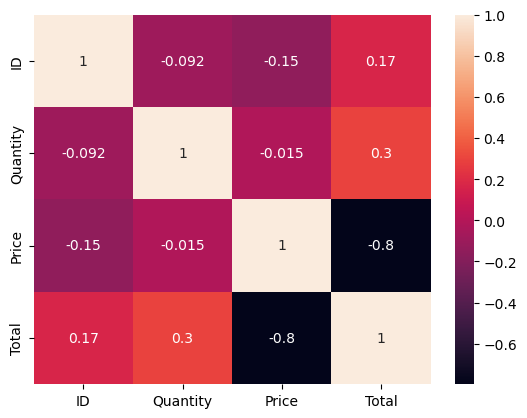

In [291]:
sns.heatmap(df.corr(numeric_only=True), annot= True)
plt.rcParams['figure.figsize']=(20,7)

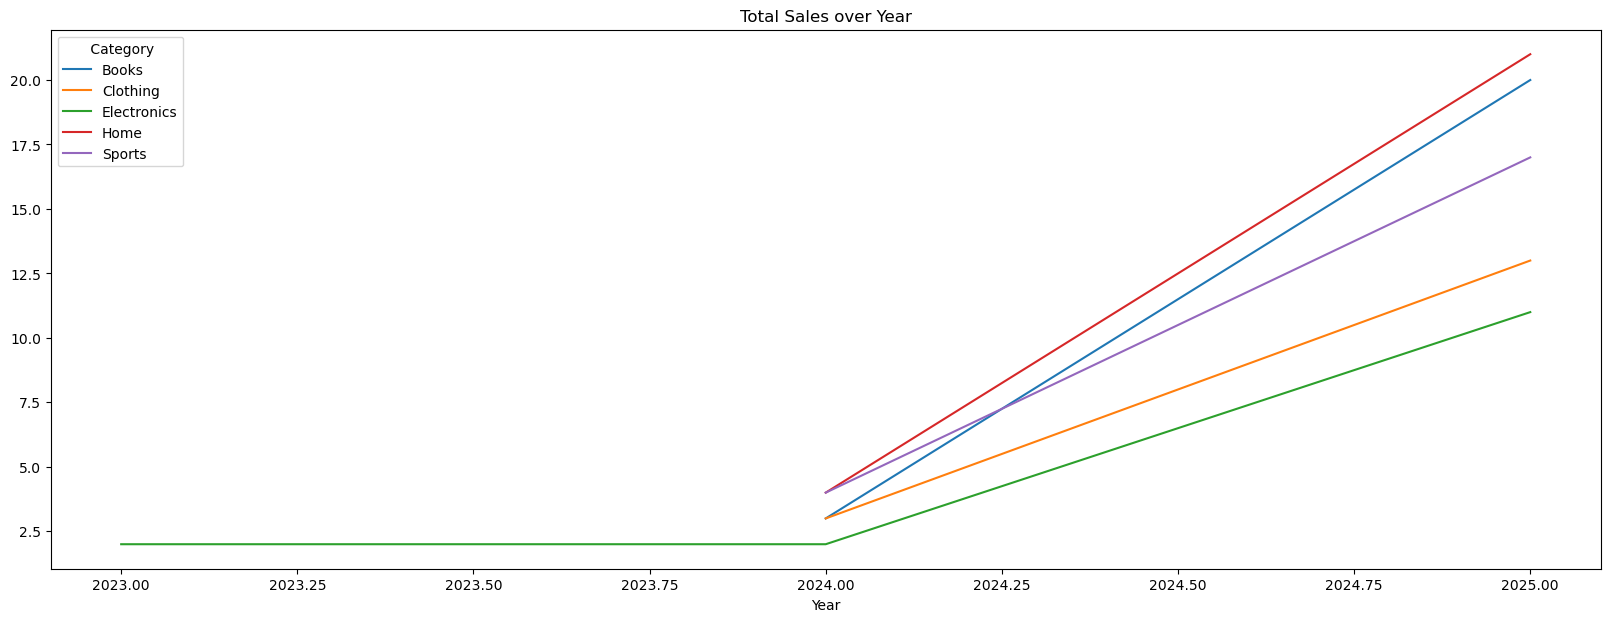

In [353]:
df.groupby(['Year',' Category']).size().unstack().plot.line(title= 'Total Sales over Year')
plt.show()

<Axes: >

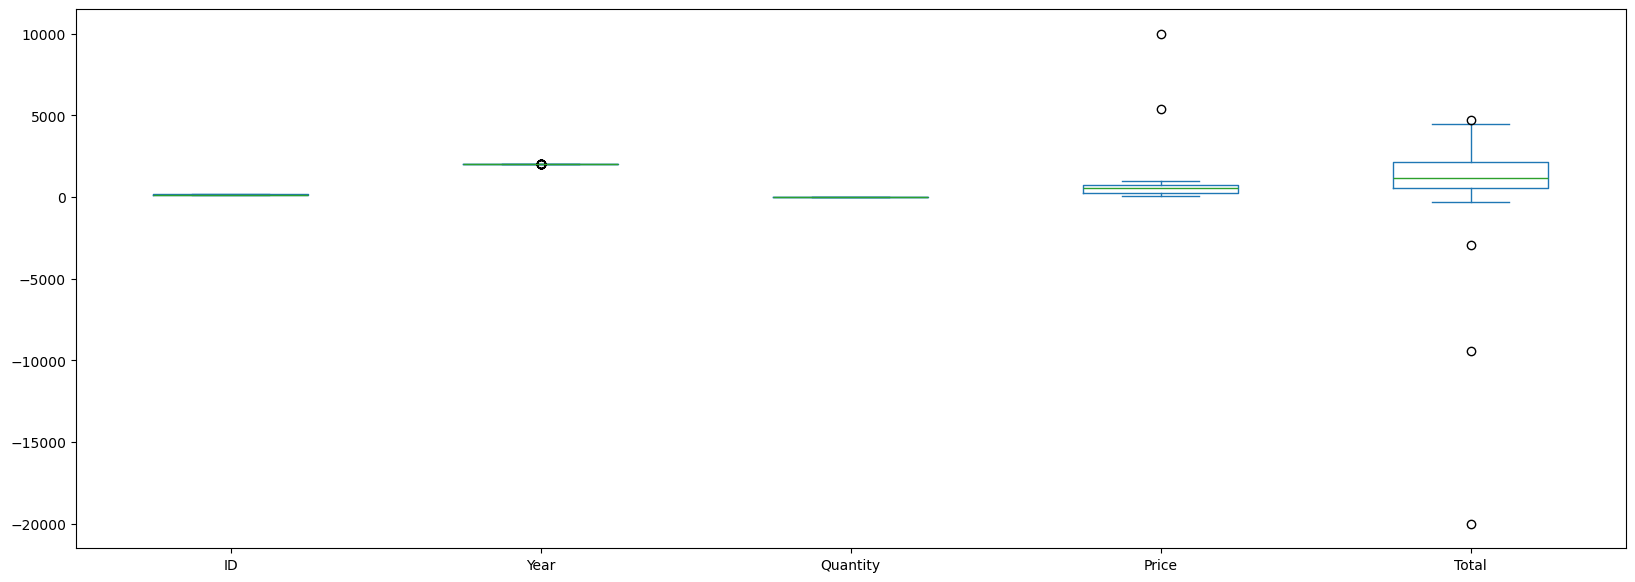

In [347]:
df.plot.box()

In [331]:
df['Year']=df['Order_Date'].dt.year


C:\Users\USER\AppData\Local\Temp\ipykernel_8816\3772775504.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df['Year']=df['Order_Date'].dt.year


In [337]:
cols=list(df.columns)
cols.insert(4,cols.pop(cols.index('Year')))
df=df[cols]

In [ ]:
df.to_csv(r'C:\Users\USER\OneDrive\Documents\dossier yaya\csv file\messi